In [1]:
# ============================================================================
# Physics-Informed Fourier Neural Operator (PI-FNO) demo using the FOLAX library
# ----------------------------------------------------------------------------
# Goal:
#   Learn an OPERATOR that maps a spatial heterogeneity field K(x,y) to the
#   displacement solution U(x,y) = [Ux(x,y), Uy(x,y)] for a 2D linear elasticity
#   problem — WITHOUT supervised labels — by minimizing a weighted FE residual loss.
#
# What FOL provides in this example:
#   1) A "control" object that generates spatial fields K from low-dim parameters
#      (here: Fourier coefficients).
#   2) A physics loss object (FE-based) that computes equilibrium
#      (includign strongly applied BC).
#   3) A training wrapper that connects: coeffs -> K -> FNO -> U -> physics loss.
# ============================================================================

In [2]:
# ----------------------------------------------------------------------------
# 0) Basic imports + create clean working directory for outputs
# ----------------------------------------------------------------------------
import sys,os
from fol.tools.usefull_functions import *

# Where all artifacts go: checkpoints, plots, exported VTK, logs, etc.
working_directory_name = 'pi_fno_2D_elasticity'
case_dir = os.path.join('.', working_directory_name)
create_clean_directory(working_directory_name)

In [3]:
# ----------------------------------------------------------------------------
# 1) Define the mechanical PDE problem and create FE mesh + FE-based loss
# ----------------------------------------------------------------------------
from fol.loss_functions.mechanical import MechanicalLoss2DQuad

# ===============================================================================
#           2D SQUARE DOMAIN Ω = [0,L] × [0,L]     (L = 1,  N = 30)
# ===============================================================================

#           y
#           ↑
#           │
#           ┌───────────────────────────┐   y = L
#           │                           │
#           │                           │
#           │                           │
#           │           Ω               │   ← square domain
#           │   (structured quad mesh)  │
#           │                           │
#           │                           │
#           │                           │
#           └───────────────────────────┘   y = 0
#           │
#           └──────────────────────────→ x
#           0                          L

# Dirichlet boundary conditions (applied on full vertical edges):
#   LEFT  (x = 0):  Ux = 0.0 ,  Uy = 0.0
#   RIGHT (x = L):  Ux = 0.05,  Uy = 0.05

# Material model:
#   Linear isotropic elasticity
#   Young's modulus E = 1
#   Poisson ratio   ν = 0.3
# ===============================================================================


# Problem settings (domain + Dirichlet BCs)
# L: domain side length
# N: resolution used to represent K(x,y) on a grid (and usually used for mesh)
# Ux_left/right, Uy_left/right: prescribed displacements on left/right boundaries
model_settings = {"L":1,"N":30,
                "Ux_left":0.0,"Ux_right":0.05,
                "Uy_left":0.0,"Uy_right":0.05}

# Create a 2D square FE mesh. Internally, creates nodes/elements
# consistent with a (structured) quad mesh on [0,L]x[0,L].
fe_mesh = create_2D_square_mesh(L=1,N=30)

# Dirichlet boundary conditions dictionary:
#   component -> side -> value
# This tells the mechanical loss what displacement is fixed on boundaries.
bc_dict = {"Ux":{"left":model_settings["Ux_left"],"right":model_settings["Ux_right"]},
            "Uy":{"left":model_settings["Uy_left"],"right":model_settings["Uy_right"]}}

# Linear elastic material parameters
material_dict = {"young_modulus":1,"poisson_ratio":0.3}

# Create an FE-based physics loss:
# MechanicalLoss2DQuad evaluates the 2D elasticity weighted residual using quadrilateral
# elements and numerical integration (Gauss points).
mechanical_loss_2d = MechanicalLoss2DQuad("mechanical_loss_2d",loss_settings={"dirichlet_bc_dict":bc_dict,
                                                                            "num_gp":2,
                                                                            "material_dict":material_dict},
                                                                            fe_mesh=fe_mesh)

# Initialize builds internal FE data structures:
# - connectivity, shape functions, gauss points/weights
# - boundary node sets for Dirichlet BC
# - material matrices, etc.
mechanical_loss_2d.Initialize()

2025-12-30 16:36:29 - Info : mechanical_loss_2d.Initialize - for the proper batching of elements, the batch size is changed from 42 to 29


2025-12-30 16:36:29 - Info : fourier_control.Initialize - finished in 0.1033 seconds


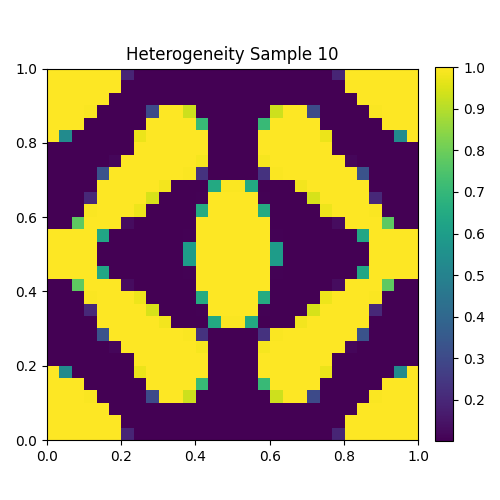

In [4]:
# ----------------------------------------------------------------------------
# 2) Define "control": parameterize the input field K(x,y) using Fourier modes
# ----------------------------------------------------------------------------

from fol.controls.fourier_control import FourierControl
from IPython.display import Image, display

# Create fourier control object tied to the FE mesh (so it can generate K on the mesh/grid)
fourier_control_settings = {"x_freqs":np.array([2,4,6]),"y_freqs":np.array([2,4,6]),"z_freqs":np.array([0]),
                            "beta":20,"min":1e-1,"max":1}
fourier_control = FourierControl("fourier_control",fourier_control_settings,fe_mesh)
fourier_control.Initialize()

# Sample random Fourier coefficients and create corresponding heterogeneity fields.
# coeffs_matrix: (n_samples, n_coeffs)  -> low-dim parameters
# K_matrix:      (n_samples, N*N) or (n_samples, N, N) -> spatial field samples
coeffs_matrix,K_matrix = create_random_fourier_samples(fourier_control,100)

plot_sample_id = 10
plot_file_name = os.path.join(case_dir,f'heterogeneity_sample_{plot_sample_id}.png')
plot_mesh_vec_data(model_settings["L"], [K_matrix[10,:]],
                   subplot_titles= [f'Heterogeneity Sample {plot_sample_id}'], fig_title=None, cmap='viridis',
                    block_bool=True, colour_bar=True, colour_bar_name=None,
                    X_axis_name=None, Y_axis_name=None, show=False,file_name=plot_file_name)
display(Image(filename=plot_file_name))

In [5]:
# ----------------------------------------------------------------------------
# 3) Build the FNO (Fourier Neural Operator) in JAX/Flax
# ----------------------------------------------------------------------------

from fol.deep_neural_networks.ported_fourier_neural_operator_networks.fno import FNO
from flax import nnx
import jax

fno_model = FNO(
    in_channels=1,
    out_channels=2,
    hidden_channels=64,
    n_modes=(12,12),
    n_layers=4,
    rngs=nnx.Rngs(0)
)

# Count trainable parameters
params = nnx.state(fno_model, nnx.Param)
total_params  = sum(np.prod(x.shape) for x in jax.tree_util.tree_leaves(params))
print(f"FNO trainable parameters:{total_params}")

# Sanity-check forward pass with a small batch:
# FNO expects shape (batch, Nx, Ny, channels)
# ISince K_matrix is stored as flattened vectors, we reshape to (B,N,N,1)
init_out = fno_model(K_matrix[0:8].reshape(8,model_settings["N"],model_settings["N"],1))

FNO trainable parameters:1427266


In [6]:
# ----------------------------------------------------------------------------
# 4) Create Physics-Informed Operator Learning wrapper (PI-FOL)
# ----------------------------------------------------------------------------

import optax
from fol.deep_neural_networks.fourier_parametric_operator_learning import PhysicsInformedFourierParametricOperatorLearning

# Optimizer for the FNO parameters.
num_epochs = 10000
optimizer = optax.chain(optax.adam(1e-6))

# This wrapper is the "glue" that performs operator learning:
# It knows how to:
#   coeffs -> control generates K
#   K -> neural net predicts U
#   U (+ K) -> physics loss computes residual/BC loss
#   optimize NN parameters using optax
pi_fno_pr_learning = PhysicsInformedFourierParametricOperatorLearning(name="pi_fno_pr_learning",
                                                                        control=fourier_control,
                                                                        loss_function=mechanical_loss_2d,
                                                                        flax_neural_network=fno_model,
                                                                        optax_optimizer=optimizer)
# Initialize the trainer
pi_fno_pr_learning.Initialize()

2025-12-30 16:36:34 - Info : pi_fno_pr_learning.Initialize - finished in 0.2063 seconds


In [7]:
# ----------------------------------------------------------------------------
# 5) Train / Test split and training call
# ----------------------------------------------------------------------------
train_start_id, train_end_id = 0, 80
test_start_id, test_end_id = 80, 100

# Train expects tuples for datasets (even if there's only one "input")
# Here: the dataset is only Fourier coefficients; K is generated internally.
#
# In physics-informed settings, "labels" aren't required because loss is physics residual.
pi_fno_pr_learning.Train(train_set=(coeffs_matrix[train_start_id:train_end_id,:],),
                        test_set=(coeffs_matrix[test_start_id:test_end_id,:],),
                        test_frequency=1000, # evaluate on test set every 1000 epochs
                        batch_size=8,
                        # Convergence criteria: extremely strict -> effectively forces full epochs
                        convergence_settings={"num_epochs":num_epochs,"relative_error":1e-100,"absolute_error":1e-100},
                        # Plot/save cadence (writes loss curves)
                        plot_settings={"plot_save_rate":1000},
                        # Checkpointing (keep best loss + periodic saves)
                        train_checkpoint_settings={"least_loss_checkpointing":True,"frequency":1000},
                        working_directory=case_dir)

display(Image(filename=os.path.join(case_dir,f'training_history.png')))

2025-12-30 16:36:34 - Info : pi_fno_pr_learning.Train - convergence settings:{'num_epochs': 10000, 'convergence_criterion': 'total_loss', 'relative_error': 1e-100, 'absolute_error': 1e-100}
2025-12-30 16:36:34 - Info : pi_fno_pr_learning.Train - plot settings:{'plot_list': ['total_loss'], 'plot_frequency': 1, 'save_frequency': 100, 'save_directory': '.\\pi_fno_2D_elasticity', 'test_frequency': 1000}
2025-12-30 16:36:34 - Info : pi_fno_pr_learning.Train - restore settings:{'restore': False, 'state_directory': '.\\pi_fno_2D_elasticity/flax_state'}
2025-12-30 16:36:34 - Info : pi_fno_pr_learning.Train - train checkpoint settings:{'least_loss_checkpointing': True, 'least_loss': inf, 'frequency': 1000, 'state_directory': '.\\pi_fno_2D_elasticity/flax_train_state'}
2025-12-30 16:36:34 - Info : pi_fno_pr_learning.Train - test checkpoint settings:{'least_loss_checkpointing': False, 'least_loss': inf, 'frequency': 100, 'state_directory': '.\\pi_fno_2D_elasticity/flax_test_state'}
2025-12-30 16:

  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\reza.najianasl\AppData\Local\anaconda3\envs\folax-doc\Lib\site-packages\jax\_src\lax\lax.py:5482: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)
c:\Users\reza.najianasl\AppData\Local\anaconda3\envs\folax-doc\Lib\site-packages\jax\_src\interpreters\mlir.py:1280: UserWarning: Some donated buffers were not usable: float32[80,10].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
  0%|          | 19/10000 [00:25<3:44:26,  1.35s/it, train_loss=1.7558943, test_loss=2.383571]


KeyboardInterrupt: 

In [ ]:
# ----------------------------------------------------------------------------
# 6) Load final trained state and run inference for all coefficient samples
# ----------------------------------------------------------------------------
# RestoreState loads weights/optimizer state saved at the end of training.
# "flax_final_state" is the folder created by the trainer.

pi_fno_pr_learning.RestoreState(restore_state_directory=case_dir+"/flax_final_state")
FNO_UVs = pi_fno_pr_learning.Predict(coeffs_matrix)

2025-12-30 09:27:47 - Info : pi_fno_pr_learning.RestoreState - flax nnx state is restored from ./pi_fno_2D_elasticity/flax_final_state
2025-12-30 09:27:52 - Info : pi_fno_pr_learning.Predict - finished in 4.3212 seconds


In [ ]:
# ----------------------------------------------------------------------------
# 7) Create an FE solver for reference (ground truth comparison)
# ----------------------------------------------------------------------------

from fol.solvers.fe_linear_residual_based_solver import FiniteElementLinearResidualBasedSolver

# Configure iterative linear solver:
# bicgstab + ILU preconditioner for sparse FE systems
fe_setting = {"linear_solver_settings":{"solver":"JAX-bicgstab","tol":1e-6,"atol":1e-6,
                                            "maxiter":1000,"pre-conditioner":"ilu"}}

# This solver uses the same mechanical_loss_2d configuration (mesh/BC/material)
fe_solver = FiniteElementLinearResidualBasedSolver("lin_fe_solver",mechanical_loss_2d,fe_setting)
fe_solver.Initialize()

2025-12-30 09:27:52 - Info : lin_fe_solver.__init__ - finished in 0.0000 seconds
2025-12-30 09:27:52 - Info : lin_fe_solver.Initialize - finished in 0.0000 seconds


2025-12-30 09:27:52 - Info : mechanical_loss_2d.ApplyDirichletBCOnDofVector - finished in 0.0344 seconds
2025-12-30 09:27:53 - Info : mechanical_loss_2d.ComputeJacobianMatrixAndResidualVector - finished in 0.9178 seconds
2025-12-30 09:27:53 - Info : lin_fe_solver.JaxBicgstabLinearSolver - finished in 0.5531 seconds
2025-12-30 09:27:53 - Info : lin_fe_solver.Solve - finished in 1.5366 seconds


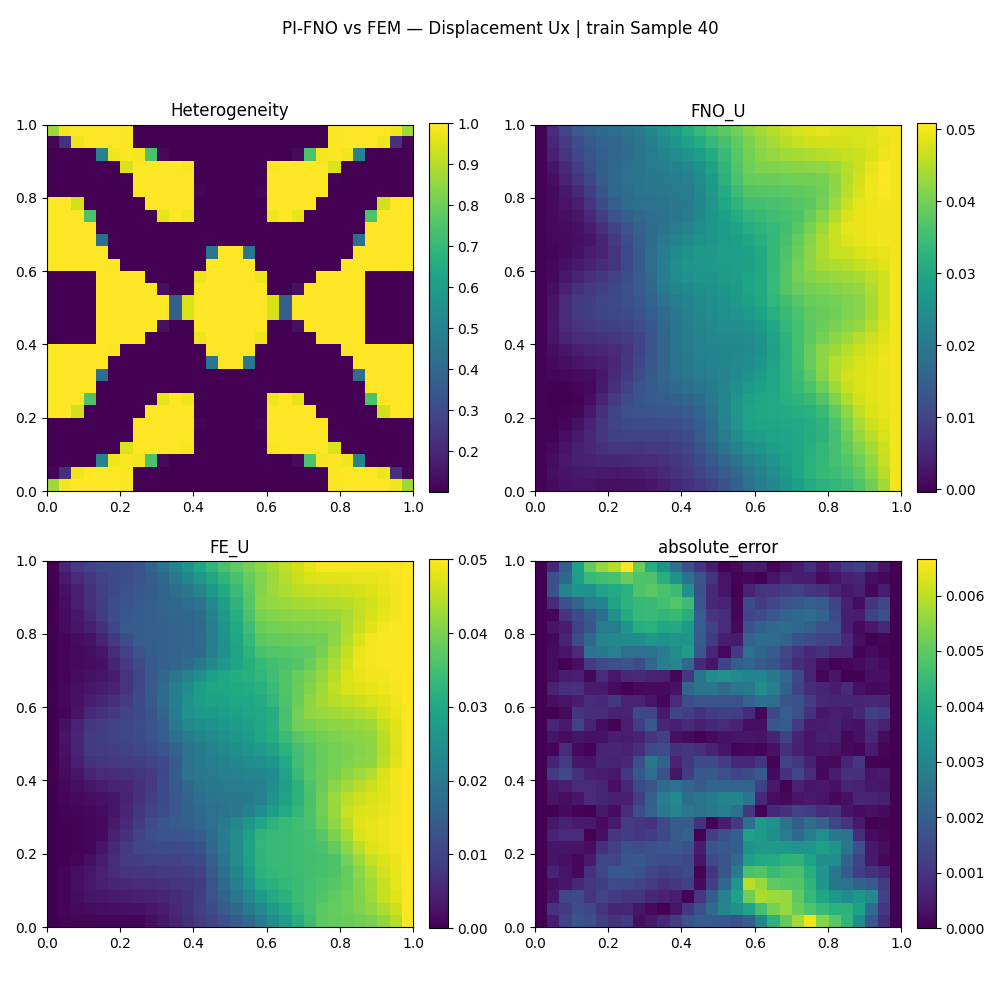

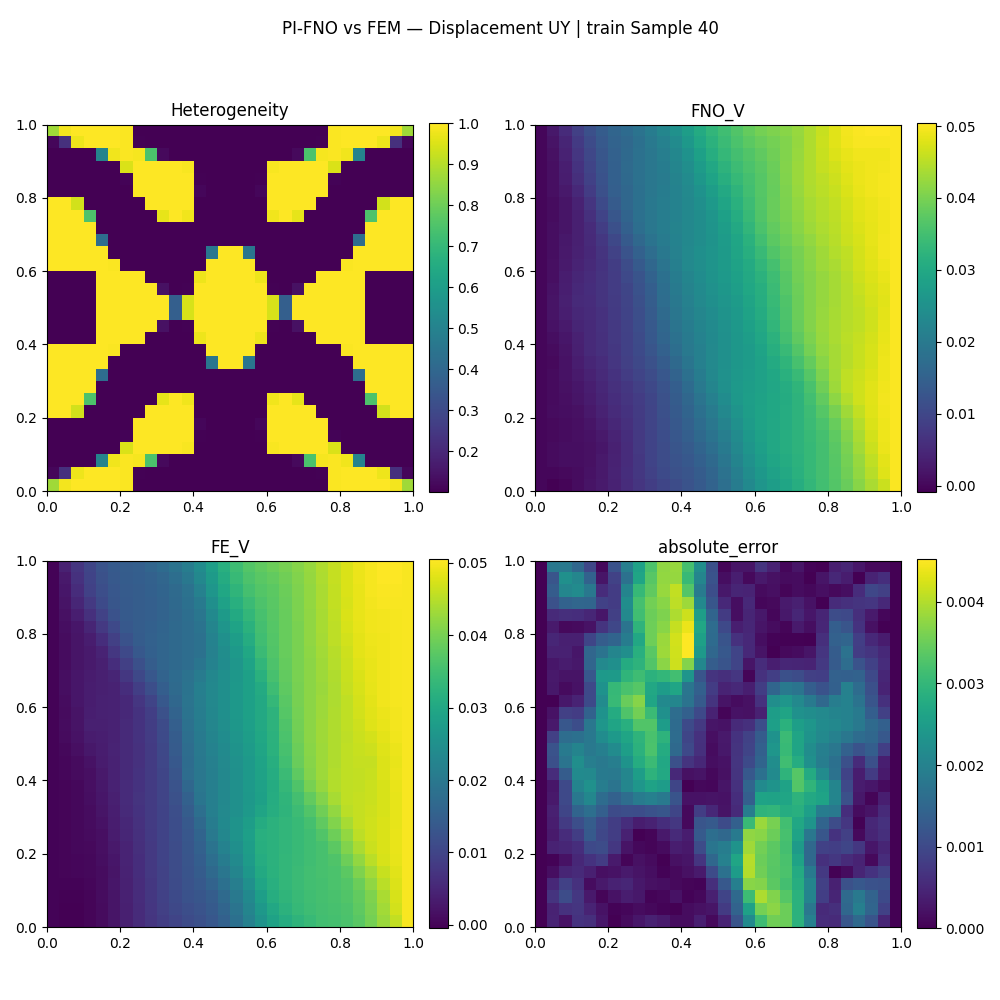

2025-12-30 09:27:54 - Info : mechanical_loss_2d.ApplyDirichletBCOnDofVector - finished in 0.0002 seconds
2025-12-30 09:27:54 - Info : mechanical_loss_2d.ComputeJacobianMatrixAndResidualVector - finished in 0.0021 seconds
2025-12-30 09:27:54 - Info : lin_fe_solver.JaxBicgstabLinearSolver - finished in 0.2311 seconds
2025-12-30 09:27:54 - Info : lin_fe_solver.Solve - finished in 0.2340 seconds


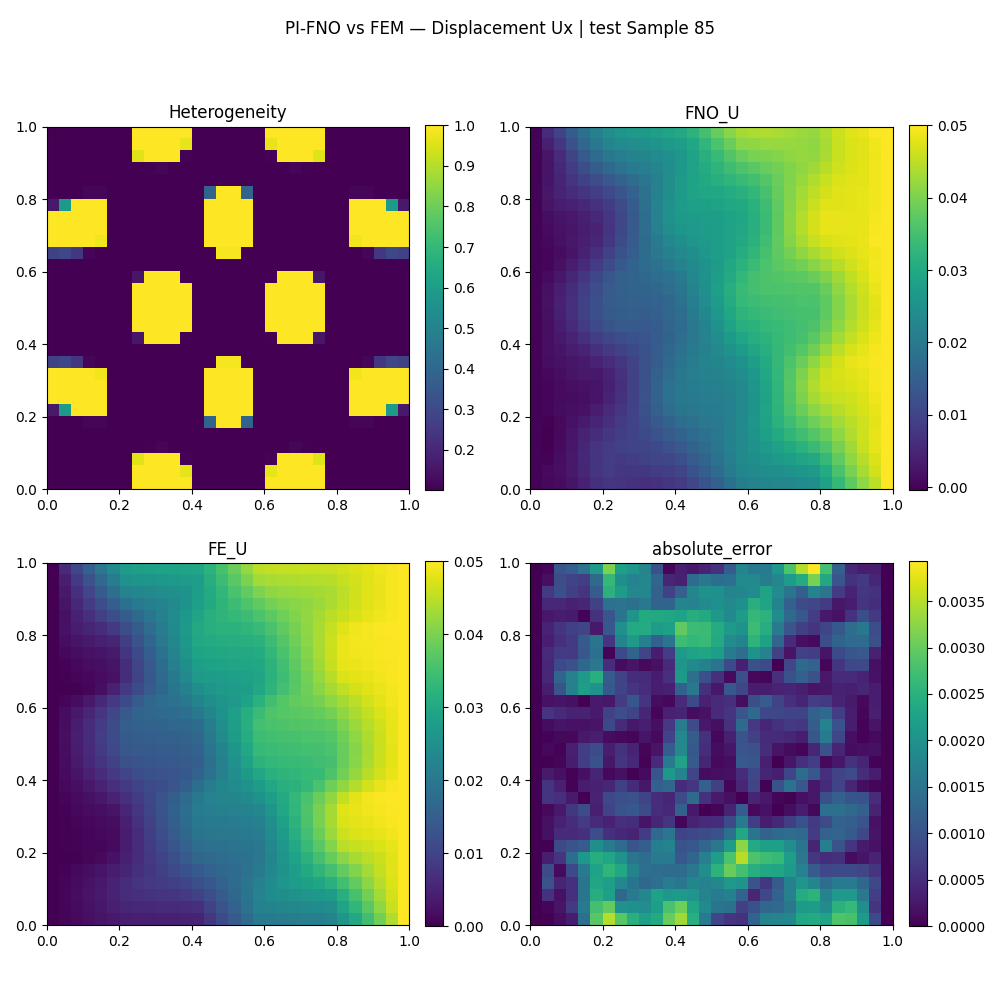

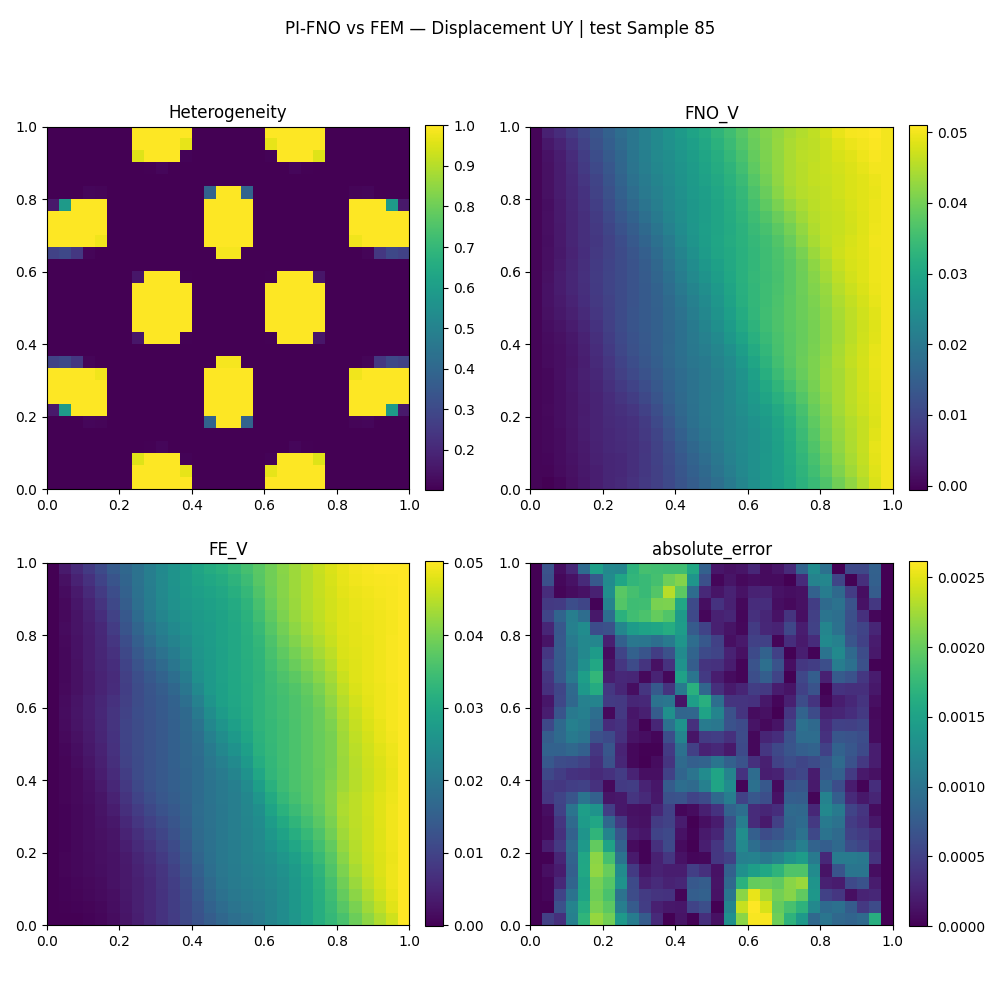

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FNO_UV_40.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FE_UV_40.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to abs_error_40.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FNO_UV_85.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to FE_UV_85.

Warning: VTK requires 3D vectors, but 2D vectors given. Appending 0 third component to abs_error_85.

2025-12-30 09:27:56 - Info : square_io.Finalize - finished in 0.0098 seconds


In [ ]:
# ----------------------------------------------------------------------------
# 8) Compare PI-FNO vs FE on a subset of train/test samples and plot results
# ----------------------------------------------------------------------------

def plot_set_results(set_ids:np.array,set_name:str):
    """
    For each sample id:
      1) Get FNO predicted displacement field.
      2) Compute FE solution with the same heterogeneity K.
      3) Compute absolute error.
      4) Plot Ux and Uy components separately (plus heterogeneity map).
      5) Store fields on mesh for export (VTK).
    """
    for eval_id in set_ids:
        # ---------------------------------------
        # (A) FNO prediction
        # ---------------------------------------
        # Convert to numpy and flatten into nodal vector ordering:
        # displacement vectors are [Ux0, Uy0, Ux1, Uy1, ...]

        FNO_UV = np.asarray(FNO_UVs[eval_id]).flatten()

        # Store on mesh (shape: n_nodes x 2) for later VTK export
        fe_mesh[f'FNO_UV_{eval_id}'] = FNO_UV.reshape((fe_mesh.GetNumberOfNodes(), 2))

        # ---------------------------------------
        # (B) FE reference solve
        # ---------------------------------------
        # Solve the FE system for this heterogeneity field K
        # RHS is zeros here (no body forces), and Dirichlet BC are handled internally.
        FE_UV = np.asarray(fe_solver.Solve(K_matrix[eval_id],np.zeros(2*fe_mesh.GetNumberOfNodes()))).flatten()

        fe_mesh[f'FE_UV_{eval_id}'] = FE_UV.reshape((fe_mesh.GetNumberOfNodes(), 2))

        # ---------------------------------------
        # (C) Error
        # ---------------------------------------
        absolute_error = abs(FNO_UV- FE_UV)
        fe_mesh[f'abs_error_{eval_id}'] = absolute_error.reshape((fe_mesh.GetNumberOfNodes(), 2))

        # ---------------------------------------
        # (D) Plot Ux and Uy separately
        # ---------------------------------------
        # Ux are even indices: 0,2,4,...
        # Uy are odd indices: 1,3,5,...
        plot_file_name = os.path.join(case_dir,f'{set_name}_{eval_id}_U.png')
        plot_mesh_vec_data(model_settings["L"], [K_matrix[eval_id,:],FNO_UV[::2],FE_UV[::2],absolute_error[::2]],
                           subplot_titles= ['Heterogeneity', 'FNO_U', 'FE_U', "absolute_error"], fig_title = (f"PI-FNO vs FEM — Displacement Ux | " f"{set_name} Sample {eval_id}"),
                           cmap='viridis',block_bool=True, colour_bar=True, colour_bar_name=None,
                           X_axis_name=None, Y_axis_name=None, show=False, file_name=plot_file_name)
        display(Image(filename=plot_file_name))


        plot_file_name = os.path.join(case_dir,f'{set_name}_{eval_id}_V.png')
        plot_mesh_vec_data(model_settings["L"], [K_matrix[eval_id,:],FNO_UV[1::2],FE_UV[1::2],absolute_error[1::2]],
                           subplot_titles= ['Heterogeneity', 'FNO_V', 'FE_V', "absolute_error"], fig_title = (f"PI-FNO vs FEM — Displacement UY | " f"{set_name} Sample {eval_id}"),
                           cmap='viridis',block_bool=True, colour_bar=True, colour_bar_name=None,
                           X_axis_name=None, Y_axis_name=None, show=False, file_name=plot_file_name)
        display(Image(filename=plot_file_name))

# Plot a few training and test samples
plot_set_results([40],"train")
plot_set_results([85],"test")

# Export everything stored on the mesh into VTK for visualization tools (ParaView)
fe_mesh.Finalize(export_dir=case_dir)